# Fig 1 — read-length distributions

One boxplot per dataset group, built from the per-read length tables that
`read_info.py` writes to `data/read_stats/read-lengths/`. Simulated reads use
per-platform lists so PacBio and ONT show as separate groups. Run that first:

```bash
python scripts/read-analysis/read_info.py \
    data/datasets_simulated_pacbio.txt data/datasets_simulated_ont.txt \
    data/datasets_mock_pacbio.txt data/datasets_mock_ont.txt \
    data/datasets_dyn_pacbio.txt data/datasets_dyn_ont.txt \
    --workers 32
```

In [4]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Anchor cwd to bakeoff/ regardless of where the notebook is executed from.
BAKEOFF_ROOT = next(
    (d for d in [Path.cwd(), *Path.cwd().parents]
     if (d / 'config' / 'bakeoff_env.yaml').is_file()),
    None,
)
if BAKEOFF_ROOT is None:
    raise RuntimeError(f'Could not locate bakeoff/ root from {Path.cwd()}')
os.chdir(BAKEOFF_ROOT)

# Per-read length tables from read_info.py, named {group}__{dataset}.csv.
LENGTHS_DIR = Path('data/read_stats/read-lengths')
OUT_DIR = Path('results/read-stats')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Groups drawn left to right; any extra group is appended after these.
GROUP_ORDER = ['simulated_pacbio', 'simulated_ont',
               'mock_pacbio', 'mock_ont',
               'dyn_pacbio', 'dyn_ont']

## Load read lengths by group

In [5]:
by_group = {}
for csv in sorted(LENGTHS_DIR.glob('*.csv')):
    group = csv.stem.split('__', 1)[0]
    by_group.setdefault(group, []).append(pd.read_csv(csv)['read_length'].to_numpy())

if not by_group:
    raise FileNotFoundError(f'No length tables in {LENGTHS_DIR}; run read_info.py first.')

lengths = {g: np.concatenate(arrs) for g, arrs in by_group.items()}
groups = [g for g in GROUP_ORDER if g in lengths] + [g for g in lengths if g not in GROUP_ORDER]
for g in groups:
    print(f'{g}: {lengths[g].size:,} reads')

simulated_pacbio: 1,239,864 reads
simulated_ont: 2,388,554 reads
mock_pacbio: 4,749,685 reads
mock_ont: 3,280,246 reads
dyn_pacbio: 22,899,330 reads
dyn_ont: 72,023,763 reads


## Fig 1 — read-length boxplot

Saved: /home/Users/pacbio_bakeoff/bakeoff/results/read-stats/fig1_read_length_boxplot.png


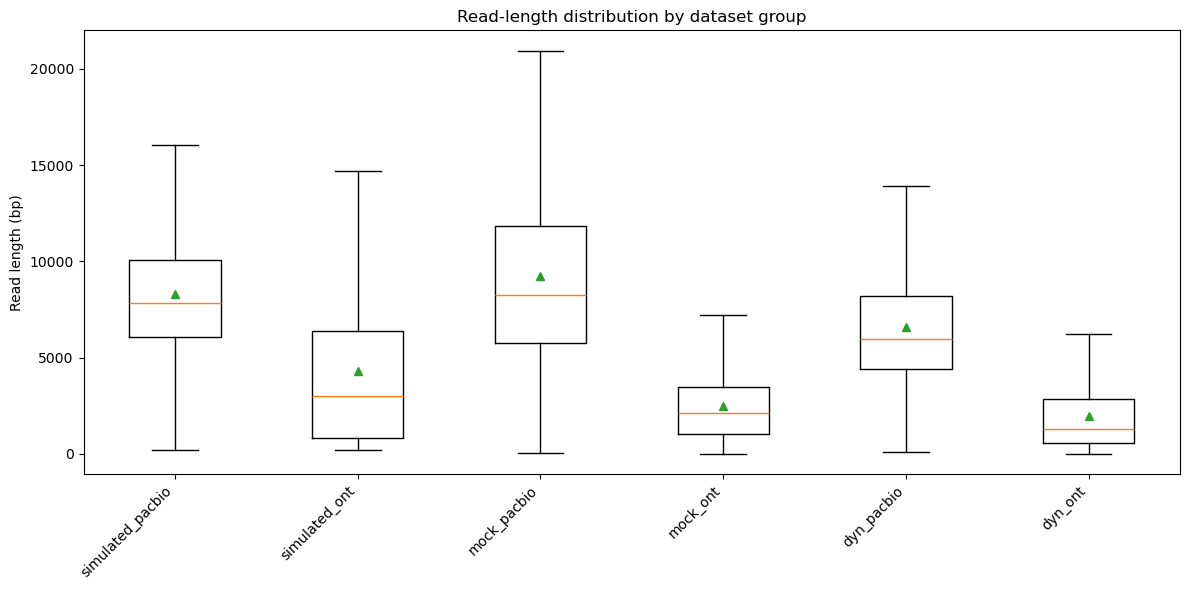

In [6]:
fig, ax = plt.subplots(figsize=(max(8, 2 * len(groups)), 6))
ax.boxplot([lengths[g] for g in groups], showmeans=True, showfliers=False)
ax.set_xticklabels(groups, rotation=45, ha='right')
ax.set_ylabel('Read length (bp)')
ax.set_title('Read-length distribution by dataset group')
fig.tight_layout()

out = OUT_DIR / 'fig1_read_length_boxplot.png'
fig.savefig(out, dpi=300)
print('Saved:', out.resolve())